# Protrusion length — U-Net vs manual quantification

Tests the U-Net's HbS-protrusion **length** accuracy on the held-out `MiniTilesForEval/` crops, independent of the pixel-classification confusion matrix (which is in `pixel_confusion_matrix.ipynb`).

The paper reports **length bias +2.9 pixels, n=161** (Figure 2d) — computed here, per matched manual-vs-model polymer pair, from the **major-axis** length of the U-Net-derived connected components (the length metric quoted throughout the paper).

## Workflow

1. **Build the grid** (already done by `tools/build_grid.py`): tiles the 100 v4 eval crops into a single `grid_10x10.png` (2560×2560). Each cell shows one eval region with a dashed dotted frame marking its boundary and surrounding 2× context.
2. **Mark protrusion endpoints in Photoshop**: open `grid_10x10.png`, use the Count tool to place markers at the endpoints of every protrusion **inside** each dashed frame. Pair them in sequence — start, end, start, end, ...
3. **Export coordinates**: run `sickling/protrusion_detection/count2csv.jsx` from the Scripts menu. Writes `grid_10x10_counts.csv` next to the PSD with `idx, x, y` per row.
4. **Run this notebook**: pairs consecutive rows, assigns each protrusion to its source crop via the layout JSON, clips manual segments to the eval region (Liang–Barsky), runs the U-Net, extracts per-connected-component major-axis lengths, and Hungarian-matches each manual polymer to its closest model CC by centroid distance.

## Outputs

- `notebooks/figures/protrusion_length_scatter.svg/png` — manual vs U-Net major-axis length per matched polymer + Bland–Altman.
- `notebooks/figures/protrusion_length_matches.csv` — one row per matched pair (manual + model side).
- `notebooks/figures/protrusion_length_per_crop.csv` — per-crop aggregates for cross-reference.
- `notebooks/figures/protrusion_length_unmatched.csv` — manual-with-no-model-match (FN) and model-CC-with-no-manual-match (FP).

In [1]:
import sys, os
from pathlib import Path

# Make the sickling package importable when running from the notebook dir.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment
from skimage.measure import regionprops
from skimage.morphology import skeletonize

from sickling.protrusion_detection.config import cfg
from sickling.protrusion_detection.inference import load_unet, predict_probs_tta, predict_probs
from sickling.protrusion_detection.masks import normalize_image

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42

print('REPO_ROOT =', REPO_ROOT)
print('device    =', cfg.DEVICE)

REPO_ROOT = E:\utku g leica\sickling-publish
device    = cuda


In [2]:
# --- inputs (edit me) ----------------------------------------------------
GRID_DIR     = Path(cfg.MINI_TILES_FOR_EVAL_DIR)
LAYOUT_JSON  = GRID_DIR / 'grid_10x10_layout.json'
COUNT_CSV    = GRID_DIR / 'grid_10x10_counts.csv'   # produced by count2csv.jsx in Photoshop
CKPT_NAME    = 'unet_fold_1_best_loop_5.pth'
USE_TTA      = True
POOL_DIR     = Path(cfg.CORRECTION_POOL_DIR)
TARGET_CLASS = 0                                     # polymer
MIN_CC_AREA  = 3                                     # ignore tiny noise CCs (matches §3.1 mining default)

FIGURES_DIR  = REPO_ROOT / 'notebooks' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not LAYOUT_JSON.exists():
    raise FileNotFoundError(f'no layout JSON at {LAYOUT_JSON}. Run tools/build_grid.py first.')
if not COUNT_CSV.exists():
    raise FileNotFoundError(
        f'no count CSV at {COUNT_CSV}. In Photoshop, open the grid PNG, drop Count markers '
        f'at polymer endpoints inside each dashed frame, then run sickling/protrusion_detection/count2csv.jsx.'
    )

with open(LAYOUT_JSON) as f:
    layout = json.load(f)
counts_df = pd.read_csv(COUNT_CSV)
print(f'layout: {layout["n_cells"]} cells, cell_size={layout["cell_size"]}, grid_side={layout["grid_side"]}')
print(f'counts: {len(counts_df)} markers, {len(counts_df) // 2} paired polymers')

layout: 100 cells, cell_size=256, grid_side=10
counts: 352 markers, 176 paired polymers


In [3]:
def _clip_segment_to_rect(s, e, xmin, ymin, xmax, ymax):
    """Liang-Barsky clip of segment (s -> e) against axis-aligned rect.

    Returns (clipped_start, clipped_end) tuple in the original (x, y) frame, or
    None if the segment is entirely outside the rect. Endpoints are kept
    if already inside; only the outside-going parts are trimmed at the
    boundary.
    """
    x0, y0 = float(s[0]), float(s[1])
    x1, y1 = float(e[0]), float(e[1])
    dx = x1 - x0
    dy = y1 - y0
    t_min, t_max = 0.0, 1.0
    for p, q in [(-dx, x0 - xmin), (dx, xmax - x0),
                 (-dy, y0 - ymin), (dy, ymax - y0)]:
        if p == 0:
            if q < 0:
                return None     # parallel to edge, entirely outside that edge
            continue
        t = q / p
        if p < 0:
            if t > t_max: return None
            if t > t_min: t_min = t
        else:
            if t < t_min: return None
            if t < t_max: t_max = t
    cs = (x0 + t_min * dx, y0 + t_min * dy)
    ce = (x0 + t_max * dx, y0 + t_max * dy)
    return cs, ce


# Pair consecutive markers (odd-index = start, even-index = end).
if len(counts_df) % 2 != 0:
    print(f'⚠️  {len(counts_df)} markers is odd; dropping the last one.')
    counts_df = counts_df.iloc[:-1]

starts = counts_df.iloc[0::2][['x', 'y']].to_numpy()
ends   = counts_df.iloc[1::2][['x', 'y']].to_numpy()

# Assign each polymer to a grid cell by midpoint of the **clipped** segment.
# (Use the marker-pair midpoint to pick the cell first, then clip against
# that cell's eval-region rectangle.)
midpoints = (starts + ends) / 2.0
cell_size = layout['cell_size']
grid_side = layout['grid_side']

cell_lookup = {(c['grid_row'], c['grid_col']): c for c in layout['cells']}

polymer_rows = []
n_full_inside = n_clipped = n_dropped = 0
for i, (s, e, m) in enumerate(zip(starts, ends, midpoints)):
    col = int(m[0] // cell_size)
    row = int(m[1] // cell_size)
    col = max(0, min(grid_side - 1, col))
    row = max(0, min(grid_side - 1, row))
    cell = cell_lookup.get((row, col))
    if cell is None:
        n_dropped += 1
        continue

    er_y, er_x = cell['eval_region_in_grid_yx']
    er_h, er_w = cell['eval_region_hw']
    xmin, ymin, xmax, ymax = er_x, er_y, er_x + er_w, er_y + er_h

    def _inside(pt):
        return (xmin <= float(pt[0]) <= xmax) and (ymin <= float(pt[1]) <= ymax)
    both_inside = _inside(s) and _inside(e)

    if both_inside:
        cs, ce = (float(s[0]), float(s[1])), (float(e[0]), float(e[1]))
        L = float(np.hypot(ce[0] - cs[0], ce[1] - cs[1]))
        n_full_inside += 1
        was_clipped = False
    else:
        clip = _clip_segment_to_rect(s, e, xmin, ymin, xmax, ymax)
        if clip is None:
            n_dropped += 1
            continue
        cs, ce = clip
        L = float(np.hypot(ce[0] - cs[0], ce[1] - cs[1]))
        n_clipped += 1
        was_clipped = True

    polymer_rows.append({
        'polymer_idx': i,
        'manual_len_px': L,
        'start_xy_raw': [float(s[0]), float(s[1])],
        'end_xy_raw':   [float(e[0]), float(e[1])],
        'start_xy_clipped': [cs[0], cs[1]],
        'end_xy_clipped':   [ce[0], ce[1]],
        'was_clipped': was_clipped,
        'grid_row': row,
        'grid_col': col,
        'source_stem':  cell['source_stem'],
        'jpg_filename': cell['jpg_filename'],
    })

polymers_df = pd.DataFrame(polymer_rows)

n_total = len(starts)
print(f'paired manual polymers: {n_total}')
print(f'  fully inside eval region : {n_full_inside}')
print(f'  partially clipped         : {n_clipped}  '
      f'(both endpoints kept where they were; segments trimmed at the frame)')
print(f'  entirely outside (dropped): {n_dropped}')
print(f'  used in comparison        : {len(polymers_df)}')

paired manual polymers: 176
  fully inside eval region : 138
  partially clipped         : 38  (both endpoints kept where they were; segments trimmed at the frame)
  entirely outside (dropped): 0
  used in comparison        : 176


In [4]:
# Per-crop: run UNet, extract per-CC stats, then Hungarian-match each
# manual polymer to a model CC by centroid distance. The matched pairs
# go into matches_df (the per-polymer scatter source). Unmatched
# manuals are model FNs; unmatched CCs are model FPs.

ckpt_path = os.path.join(cfg.MODELS_DIR, CKPT_NAME)
model = load_unet(ckpt_path, device=cfg.DEVICE).eval()
predict = predict_probs_tta if USE_TTA else predict_probs


def _safe_tile_size(img_h, img_w, cap=cfg.TILE_SIZE):
    """Largest multiple of 16 <= min(img_h, img_w, cap). UNet downsamples
    by 16 total, so non-multiple-of-16 inputs cause skip-connection size
    mismatches."""
    raw = min(img_h, img_w, cap)
    ts = (raw // 16) * 16
    return max(ts, 16)


crop_groups = polymers_df.groupby('jpg_filename', sort=False)
per_crop_records: list[dict] = []
match_records:    list[dict] = []
unmatched_records: list[dict] = []

for jpg_name, sub in crop_groups:
    cell = next(c for c in layout['cells'] if c['jpg_filename'] == jpg_name)
    crop_path = GRID_DIR / jpg_name
    if not crop_path.exists():
        print(f'⚠️  missing crop {jpg_name}; skipping.')
        continue

    raw = np.array(Image.open(crop_path).convert('L'), dtype=np.float32)
    t = torch.from_numpy(normalize_image(raw)).float().unsqueeze(0).to(cfg.DEVICE)
    ts = _safe_tile_size(t.shape[-2], t.shape[-1])
    with torch.no_grad():
        probs = predict(model, t, tile_size=ts)
    pred = torch.argmax(probs, dim=0).cpu().numpy()

    cropH, cropW = pred.shape
    evalH, evalW = cell['eval_region_hw']
    er_top  = (cropH - evalH) // 2
    er_left = (cropW - evalW) // 2
    eval_pred = pred[er_top:er_top + evalH, er_left:er_left + evalW]
    er_grid_y, er_grid_x = cell['eval_region_in_grid_yx']

    # Per-CC model stats inside the eval region.
    polymer_mask = (eval_pred == TARGET_CLASS)
    labelled, n_cc = ndi.label(polymer_mask)
    skel = skeletonize(polymer_mask).astype(bool)

    ccs = []
    for cc_id in range(1, n_cc + 1):
        cc = (labelled == cc_id)
        area = int(cc.sum())
        if area < MIN_CC_AREA:
            continue
        cc_skel = int((skel & cc).sum())
        props = regionprops(cc.astype(np.int32))
        if not props:
            continue
        # regionprops centroid is (row, col) = (y, x) in eval-region coords.
        cy, cx = float(props[0].centroid[0]), float(props[0].centroid[1])
        ccs.append({
            'cc_id':            cc_id,
            'skel_len_px':      cc_skel,
            'major_axis_px':    float(props[0].major_axis_length),
            'area_px':          area,
            'centroid_y_eval':  cy,
            'centroid_x_eval':  cx,
        })

    # Manual polymers in this crop, mapped to eval-region coords. We use
    # the CLIPPED segment's midpoint so the matching is anchored to where
    # the polymer actually lives inside the graded region.
    manuals = []
    for _, row in sub.iterrows():
        sx, sy = float(row['start_xy_clipped'][0]), float(row['start_xy_clipped'][1])
        ex, ey = float(row['end_xy_clipped'][0]),   float(row['end_xy_clipped'][1])
        mid_x_grid = (sx + ex) / 2.0
        mid_y_grid = (sy + ey) / 2.0
        manuals.append({
            'polymer_idx':   int(row['polymer_idx']),
            'manual_len_px': float(row['manual_len_px']),
            'mid_y_eval':    mid_y_grid - er_grid_y,
            'mid_x_eval':    mid_x_grid - er_grid_x,
        })

    # Hungarian one-to-one match minimising sum of centroid distances.
    matched_m: set[int] = set()
    matched_c: set[int] = set()
    if manuals and ccs:
        D = np.zeros((len(manuals), len(ccs)))
        for i, m in enumerate(manuals):
            for j, c in enumerate(ccs):
                D[i, j] = float(np.hypot(m['mid_y_eval'] - c['centroid_y_eval'],
                                         m['mid_x_eval'] - c['centroid_x_eval']))
        rows_i, cols_j = linear_sum_assignment(D)
        for i, j in zip(rows_i, cols_j):
            matched_m.add(int(i))
            matched_c.add(int(j))
            match_records.append({
                'jpg_filename':         jpg_name,
                'grid_row':             cell['grid_row'],
                'grid_col':             cell['grid_col'],
                'eval_h':               evalH,
                'eval_w':               evalW,
                'polymer_idx':          manuals[i]['polymer_idx'],
                'manual_len_px':        manuals[i]['manual_len_px'],
                'model_cc_id':          ccs[j]['cc_id'],
                'model_skel_len_px':    ccs[j]['skel_len_px'],
                'model_major_axis_px':  ccs[j]['major_axis_px'],
                'centroid_distance_px': float(D[i, j]),
            })

    # Unmatched manuals = UNet false negatives (no model CC found).
    for i, m in enumerate(manuals):
        if i not in matched_m:
            unmatched_records.append({
                'jpg_filename': jpg_name,
                'grid_row':     cell['grid_row'],
                'grid_col':     cell['grid_col'],
                'kind':         'manual_no_match (model_FN)',
                'polymer_idx':  m['polymer_idx'],
                'len_px':       m['manual_len_px'],
            })
    # Unmatched model CCs = UNet false positives (no manual marker).
    for j, c in enumerate(ccs):
        if j not in matched_c:
            unmatched_records.append({
                'jpg_filename': jpg_name,
                'grid_row':     cell['grid_row'],
                'grid_col':     cell['grid_col'],
                'kind':         'model_cc_no_match (model_FP)',
                'model_cc_id':  c['cc_id'],
                'len_px':       c['skel_len_px'],
            })

    # Per-crop totals (cross-reference; the primary scatter is now per pair).
    manual_lens = np.array([m['manual_len_px'] for m in manuals])
    eval_diag = float(np.hypot(evalH, evalW))
    if len(manual_lens) and manual_lens.max() > eval_diag + 1e-3:
        print(f'⚠️  {jpg_name}: a manual polymer length ({manual_lens.max():.1f}) '
              f'exceeds the eval-region diagonal ({eval_diag:.1f}). Investigate.')
    per_crop_records.append({
        'jpg_filename':              jpg_name,
        'source_stem':               cell['source_stem'],
        'grid_row':                  cell['grid_row'],
        'grid_col':                  cell['grid_col'],
        'eval_h':                    evalH,
        'eval_w':                    evalW,
        'eval_diag_px':              eval_diag,
        'n_manual_polymers':         int(len(manuals)),
        'n_model_ccs':               int(len(ccs)),
        'n_matched_pairs':           int(len(matched_m)),
        'manual_total_len_px':       float(manual_lens.sum()) if len(manual_lens) else 0.0,
        'model_skeleton_total_px':   int(sum(c['skel_len_px'] for c in ccs)),
        'model_major_axis_total_px': float(sum(c['major_axis_px'] for c in ccs)),
    })

del model
per_crop_df  = pd.DataFrame(per_crop_records)
matches_df   = pd.DataFrame(match_records)
unmatched_df = pd.DataFrame(unmatched_records)

n_fn = int((unmatched_df['kind'] == 'manual_no_match (model_FN)').sum()) if len(unmatched_df) else 0
n_fp = int((unmatched_df['kind'] == 'model_cc_no_match (model_FP)').sum()) if len(unmatched_df) else 0
print(f'{len(per_crop_df)} crops compared.')
print(f'  matched pairs              : {len(matches_df)}')
print(f'  unmatched manual (model FN): {n_fn}')
print(f'  unmatched model CC (model FP): {n_fp}')
if len(matches_df):
    print(f'  matched-pair centroid distance: '
          f'median {matches_df["centroid_distance_px"].median():.1f} px, '
          f'max {matches_df["centroid_distance_px"].max():.1f} px')
print()
print('row/col indexing is 0-based. To find the cell visually:')
print(f'  - cell at grid_row=R, grid_col=C occupies pixel range '
      f'y in [R*{layout["cell_size"]}, (R+1)*{layout["cell_size"]}), '
      f'x in [C*{layout["cell_size"]}, (C+1)*{layout["cell_size"]})')
print('  - in a Photoshop/image viewer counting rows from 1, that\'s row R+1, col C+1.')

E:\utku g leica\sickling-publish\sickling\protrusion_detection\py_modules\inference.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ck

92 crops compared.
  matched pairs              : 161
  unmatched manual (model FN): 15
  unmatched model CC (model FP): 35
  matched-pair centroid distance: median 3.2 px, max 56.3 px

row/col indexing is 0-based. To find the cell visually:
  - cell at grid_row=R, grid_col=C occupies pixel range y in [R*256, (R+1)*256), x in [C*256, (C+1)*256)
  - in a Photoshop/image viewer counting rows from 1, that's row R+1, col C+1.


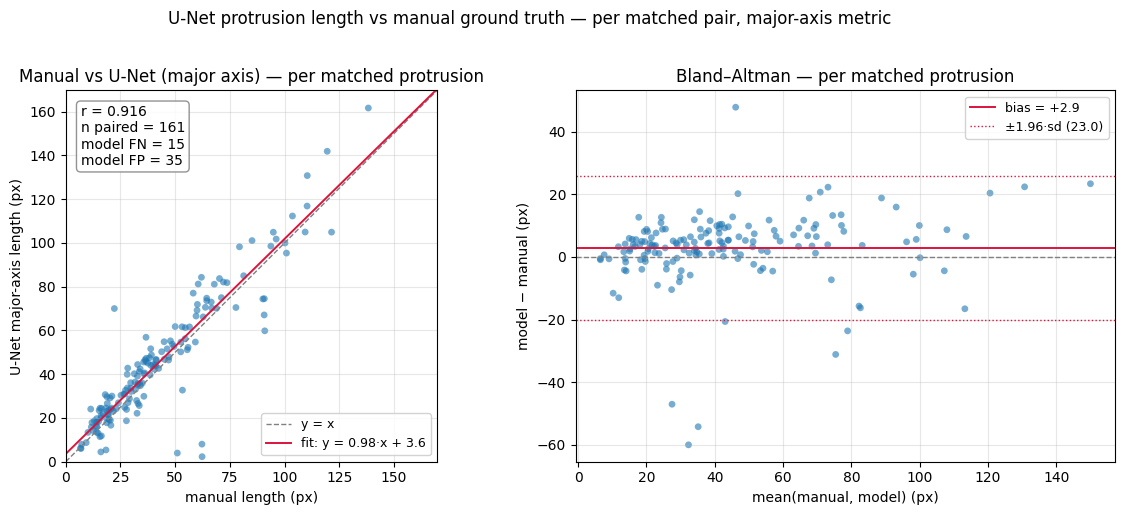

wrote: E:\utku g leica\sickling-publish\notebooks\figures\protrusion_length_scatter.svg
wrote: E:\utku g leica\sickling-publish\notebooks\figures\protrusion_length_scatter.png


In [5]:
def _scatter_panel(ax, x, y, title, xlabel, ylabel, n_fn=0, n_fp=0):
    ax.scatter(x, y, s=24, alpha=0.6, edgecolors='none')
    lim = float(max(float(np.nanmax(x)) if len(x) else 0,
                    float(np.nanmax(y)) if len(y) else 0, 1)) * 1.05
    ax.plot([0, lim], [0, lim], color='gray', linewidth=1, linestyle='--', label='y = x')
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(0, lim, 100)
        ax.plot(xs, m * xs + b, color='crimson', linewidth=1.4, label=f'fit: y = {m:.2f}·x + {b:.1f}')
        r = np.corrcoef(x, y)[0, 1]
        info = f'r = {r:.3f}\nn paired = {len(x)}'
        if n_fn or n_fp:
            info += f'\nmodel FN = {n_fn}\nmodel FP = {n_fp}'
        ax.text(0.04, 0.96, info,
                transform=ax.transAxes, va='top', ha='left', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.85))
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', fontsize=9, framealpha=0.85)


def _bland_altman_panel(ax, manual, model, title):
    mean = (manual + model) / 2.0
    diff = model - manual
    md = float(np.mean(diff)); sd = float(np.std(diff))
    ax.scatter(mean, diff, s=24, alpha=0.6, edgecolors='none')
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')
    ax.axhline(md, color='crimson', linewidth=1.4, label=f'bias = {md:+.1f}')
    ax.axhline(md + 1.96 * sd, color='crimson', linewidth=1, linestyle=':',
               label=f'±1.96·sd ({1.96 * sd:.1f})')
    ax.axhline(md - 1.96 * sd, color='crimson', linewidth=1, linestyle=':')
    ax.set_xlabel('mean(manual, model) (px)')
    ax.set_ylabel('model − manual (px)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=9, framealpha=0.85)


# Major-axis length is the metric quoted in the paper (Figure 2d:
# +2.9 px bias, n=161). Skeleton length was explored during development
# but is not reported anywhere in the manuscript, so we don't plot it.
x = matches_df['manual_len_px'].to_numpy()
y = matches_df['model_major_axis_px'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
_scatter_panel(
    axes[0], x, y,
    'Manual vs U-Net (major axis) — per matched protrusion',
    'manual length (px)',
    'U-Net major-axis length (px)',
    n_fn=n_fn, n_fp=n_fp,
)
_bland_altman_panel(axes[1], x, y, 'Bland–Altman — per matched protrusion')
fig.suptitle(
    'U-Net protrusion length vs manual ground truth — per matched pair, major-axis metric',
    y=1.02,
)
fig.tight_layout()
svg_path = FIGURES_DIR / 'protrusion_length_scatter.svg'
png_path = FIGURES_DIR / 'protrusion_length_scatter.png'
fig.savefig(svg_path, bbox_inches='tight')
fig.savefig(png_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'wrote: {svg_path}')
print(f'wrote: {png_path}')

In [6]:
# Per-crop totals (cross-reference; primary metric is per matched pair below).
per_crop_csv = FIGURES_DIR / 'protrusion_length_per_crop.csv'
# Skeleton totals are dropped from the export because skeleton length is
# not reported anywhere in the paper.
per_crop_export = per_crop_df.drop(
    columns=[c for c in ('model_skeleton_total_px',) if c in per_crop_df.columns],
)
per_crop_export.to_csv(per_crop_csv, index=False)
print(f'wrote: {per_crop_csv}')

# Per-polymer (manual side) — Liang-Barsky-clipped lengths and start/end.
cell_meta = {(c['grid_row'], c['grid_col']): c for c in layout['cells']}
per_polymer_out = polymers_df.copy()
per_polymer_out['eval_h'] = per_polymer_out.apply(
    lambda r: cell_meta[(r['grid_row'], r['grid_col'])]['eval_region_hw'][0], axis=1)
per_polymer_out['eval_w'] = per_polymer_out.apply(
    lambda r: cell_meta[(r['grid_row'], r['grid_col'])]['eval_region_hw'][1], axis=1)
per_polymer_out['eval_diag_px'] = np.hypot(per_polymer_out['eval_h'], per_polymer_out['eval_w'])
per_polymer_out = per_polymer_out[[
    'polymer_idx', 'grid_row', 'grid_col', 'jpg_filename', 'source_stem',
    'eval_h', 'eval_w', 'eval_diag_px',
    'manual_len_px', 'was_clipped',
    'start_xy_raw', 'end_xy_raw', 'start_xy_clipped', 'end_xy_clipped',
]]
per_polymer_csv = FIGURES_DIR / 'protrusion_length_per_polymer.csv'
per_polymer_out.to_csv(per_polymer_csv, index=False)
print(f'wrote: {per_polymer_csv}')

# THE matched-pair table — primary input to the per-pair scatter.
# Drop skeleton column (not reported in the paper).
matches_export = matches_df.drop(
    columns=[c for c in ('model_skel_len_px',) if c in matches_df.columns],
)
matches_csv = FIGURES_DIR / 'protrusion_length_matches.csv'
matches_export.to_csv(matches_csv, index=False)
print(f'wrote: {matches_csv}')

# Unmatched manual polymers (model FNs) + unmatched model CCs (model FPs).
unmatched_csv = FIGURES_DIR / 'protrusion_length_unmatched.csv'
unmatched_df.to_csv(unmatched_csv, index=False)
print(f'wrote: {unmatched_csv}')

# ==== Summary stats — major axis only (the paper metric) ====
m = matches_df['manual_len_px']
p = matches_df['model_major_axis_px']
r = float(np.corrcoef(m, p)[0, 1]) if len(m) >= 2 else float('nan')
bias = float((p - m).mean())
rmse = float(np.sqrt(((p - m) ** 2).mean()))
print()
print(f'==== per matched protrusion — major-axis metric (n = {len(matches_df)}) ====')
print(f'  Pearson r    = {r:.3f}')
print(f'  bias         = {bias:+.2f} px  (paper reports +2.9 px)')
print(f'  RMSE         = {rmse:.2f} px')

# Cross-reference: per-crop-totals correlation.
mc = per_crop_df['manual_total_len_px']
pc = per_crop_df['model_major_axis_total_px']
r_c  = float(np.corrcoef(mc, pc)[0, 1]) if len(mc) >= 2 else float('nan')
bias_c = float((pc - mc).mean())
rmse_c = float(np.sqrt(((pc - mc) ** 2).mean()))
print()
print(f'==== per-crop total lengths — major-axis (n = {len(per_crop_df)}, cross-reference) ====')
print(f'  Pearson r    = {r_c:.3f}')
print(f'  bias         = {bias_c:+.2f} px')
print(f'  RMSE         = {rmse_c:.2f} px')

# Unmatched diagnostics.
print()
print('==== unmatched (model errors) ====')
print(f'  model FN (manual protrusion with no nearby U-Net CC): {n_fn}')
print(f'  model FP (U-Net CC with no nearby manual marker)    : {n_fp}')

wrote: E:\utku g leica\sickling-publish\notebooks\figures\protrusion_length_per_crop.csv
wrote: E:\utku g leica\sickling-publish\notebooks\figures\protrusion_length_per_polymer.csv
wrote: E:\utku g leica\sickling-publish\notebooks\figures\protrusion_length_matches.csv
wrote: E:\utku g leica\sickling-publish\notebooks\figures\protrusion_length_unmatched.csv

==== per matched protrusion — major-axis metric (n = 161) ====
  Pearson r    = 0.916
  bias         = +2.85 px  (paper reports +2.9 px)
  RMSE         = 12.09 px

==== per-crop total lengths — major-axis (n = 92, cross-reference) ====
  Pearson r    = 0.837
  bias         = +5.14 px
  RMSE         = 27.56 px

==== unmatched (model errors) ====
  model FN (manual protrusion with no nearby U-Net CC): 15
  model FP (U-Net CC with no nearby manual marker)    : 35
